In [1]:
# National Parks & Extreme Climate

In [2]:
# Import required packages
import requests
import pandas as pd
import json
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt


### National Park Service / System Data

In [3]:
# National Park Service API Set Up
nps_url_base = "developer.nps.gov/api/v1"

my_api_key = 'your_api_key_here'

nps_url_request = "https://developer.nps.gov/api/v1/parks?limit=500&get=designation,fullName,id,name,parkCode,states&for=parkCode:*&api_key=" + my_api_key

# need to update limit to 500 for full run

In [4]:
# Execute API request
response = requests.get(nps_url_request)

In [5]:
# Check status of API request, report status, and if good transform data into dataframe and print column names
if response.status_code == 200:
    print('Successful API download')
    nps_api_exp = json.loads(response.text)
    nps_data = pd.DataFrame(nps_api_exp['data'])
    print(nps_data.columns)
else: print(f'API download failed. Error code: {response.status_code}')

Successful API download
Index(['id', 'url', 'fullName', 'parkCode', 'description', 'latitude',
       'longitude', 'latLong', 'activities', 'topics', 'states', 'contacts',
       'entranceFees', 'entrancePasses', 'fees', 'directionsInfo',
       'directionsUrl', 'operatingHours', 'addresses', 'images', 'weatherInfo',
       'name', 'designation', 'multimedia', 'relevanceScore'],
      dtype='object')


In [6]:
# View request output
#response.text

In [7]:
#nps_data.head()

In [8]:
# Select parameters of interest from API data set
nps_sites = nps_data[['fullName','name','parkCode','designation','states']]

# Rename columns
nps_sites = nps_sites.rename(columns={'fullName': 'Site_Full_Name', 'name': 'Site_Name', 'parkCode': 'Park_Code', 'designation': 'Designation', 'states': 'State List'})

#nps_sites.head()

In [9]:
# Replace blank designations with "Undefined"
nps_sites['Designation'].replace("", 'Undefined', inplace=True)

# Capitalize park code for consistent formatting
nps_sites['Park_Code'] = nps_sites['Park_Code'].str.upper()

nps_sites.head(30)

# Verify all missing designations have been addressed
#missing_desig = nps_sites[nps_sites['Designation']=='']

#print(missing_desig.shape)

#missing_desig

C:\Users\eenoo\AppData\Local\Temp\ipykernel_24892\36315879.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nps_sites['Designation'].replace("", 'Undefined', inplace=True)


,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
3,African American Civil War Memorial,African American Civil War Memorial,AFAM,Undefined,DC
4,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
5,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE
6,Ala Kahakai National Historic Trail,Ala Kahakai,ALKA,National Historic Trail,HI
7,Alagnak Wild River,Alagnak,ALAG,Wild River,AK
8,Alaska Public Lands,Alaska Public Lands,ANCH,Undefined,AK
9,Alcatraz Island,Alcatraz Island,ALCA,Undefined,CA


In [10]:
nps_sites['Designation'].unique()

array(['National Historical Park', 'National Park', 'Undefined',
       'National Monument', 'National Historic Trail', 'Wild River',
       'National Historic Area', 'National Historic Site', 'Park',
       'National Recreation Area', 'National Monument & Preserve',
       'National Battlefield', 'National Lakeshore',
       'National Scenic Trail', 'National Memorial', 'National Seashore',
       'Parkway', 'National Preserve', 'National River & Recreation Area',
       'National Scenic River', 'National Battlefield Site',
       'National River', 'Part of Colonial National Historical Park',
       'National Military Park', 'National Reserve',
       'National Park & Preserve', 'Memorial',
       'National Historical Reserve',
       'Part of Statue of Liberty National Monument',
       'National Monument and Historic Shrine', 'Memorial Parkway',
       'National Geologic Trail', 'National Historical Park and Preserve',
       'National Battlefield Park', 'National Wild and Scenic Ri

In [11]:
# Break out list of sites by individual states
# (will include duplicate listings for parks spanning multiple states)
nps_sites_state = nps_sites[['Park_Code','State List']]

#nps_sites_state['State Abb'] = nps_sites['State List']

nps_sites_state['State Abb'] = (nps_sites_state['State List'].str.split(','))

nps_sites_state = nps_sites_state.explode('State Abb')

nps_sites_state = nps_sites_state.reset_index(drop=True)


#nps_sites_state.head(30)

C:\Users\eenoo\AppData\Local\Temp\ipykernel_24892\2549278083.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nps_sites_state['State Abb'] = (nps_sites_state['State List'].str.split(','))


In [12]:
#nps_sites_state[nps_sites_state['Park_Code']=='APPA'].head(15)

In [13]:
# List of State Abbreviations in Alphabetical Order

state_abb_alpha = sorted(nps_sites_state['State Abb'].unique())

#state_abb_alpha

In [14]:
# List of State Abbreviations in Order of Site Count
state_desc_order = nps_sites_state['State Abb'].value_counts().index

In [15]:
# List of Designations in Order of Site Count
desig_desc_order = nps_sites['Designation'].value_counts().index

In [16]:
# List of Designations in Alphabetical Order
desig_alpha = sorted(nps_sites['Designation'].unique())
desig_alpha

['Affiliated Area',
 'Ecological & Historic Preserve',
 'International Historic Site',
 'International Park',
 'Memorial',
 'Memorial Parkway',
 'National Battlefield',
 'National Battlefield Park',
 'National Battlefield Site',
 'National Geologic Trail',
 'National Historic Area',
 'National Historic Site',
 'National Historic Trail',
 'National Historical Park',
 'National Historical Park and Ecological Preserve',
 'National Historical Park and Preserve',
 'National Historical Reserve',
 'National Lakeshore',
 'National Memorial',
 'National Military Park',
 'National Monument',
 'National Monument & Preserve',
 'National Monument and Historic Shrine',
 'National Park',
 'National Park & Preserve',
 'National Parks',
 'National Preserve',
 'National Recreation Area',
 'National Recreational River',
 'National Reserve',
 'National River',
 'National River & Recreation Area',
 'National Scenic River',
 'National Scenic Riverway',
 'National Scenic Riverways',
 'National Scenic Trail',

### NPS Site Visualizations

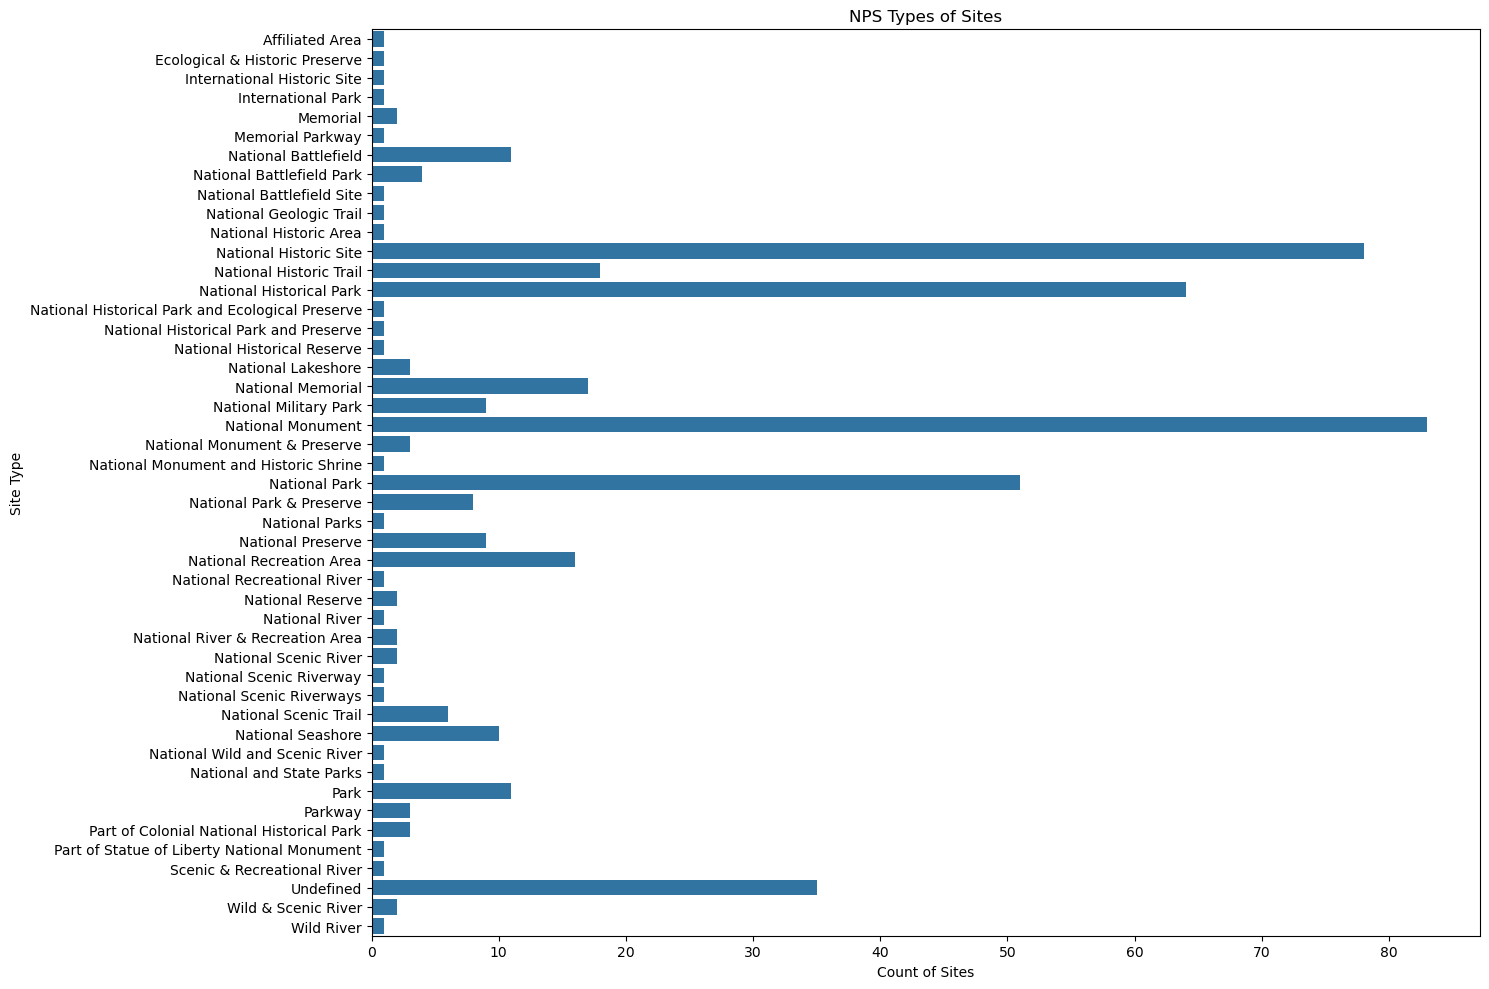

In [17]:
# Count of number of sites that fall under each designation (type of site)
plt.figure(figsize=(15, 10))#
sns.countplot(data=nps_sites, y='Designation', order = desig_alpha)
plt.title(f'NPS Types of Sites')
plt.ylabel('Site Type')
plt.xlabel('Count of Sites')
plt.subplots_adjust(left=0.3)
plt.tight_layout()

plt.show(block=False)


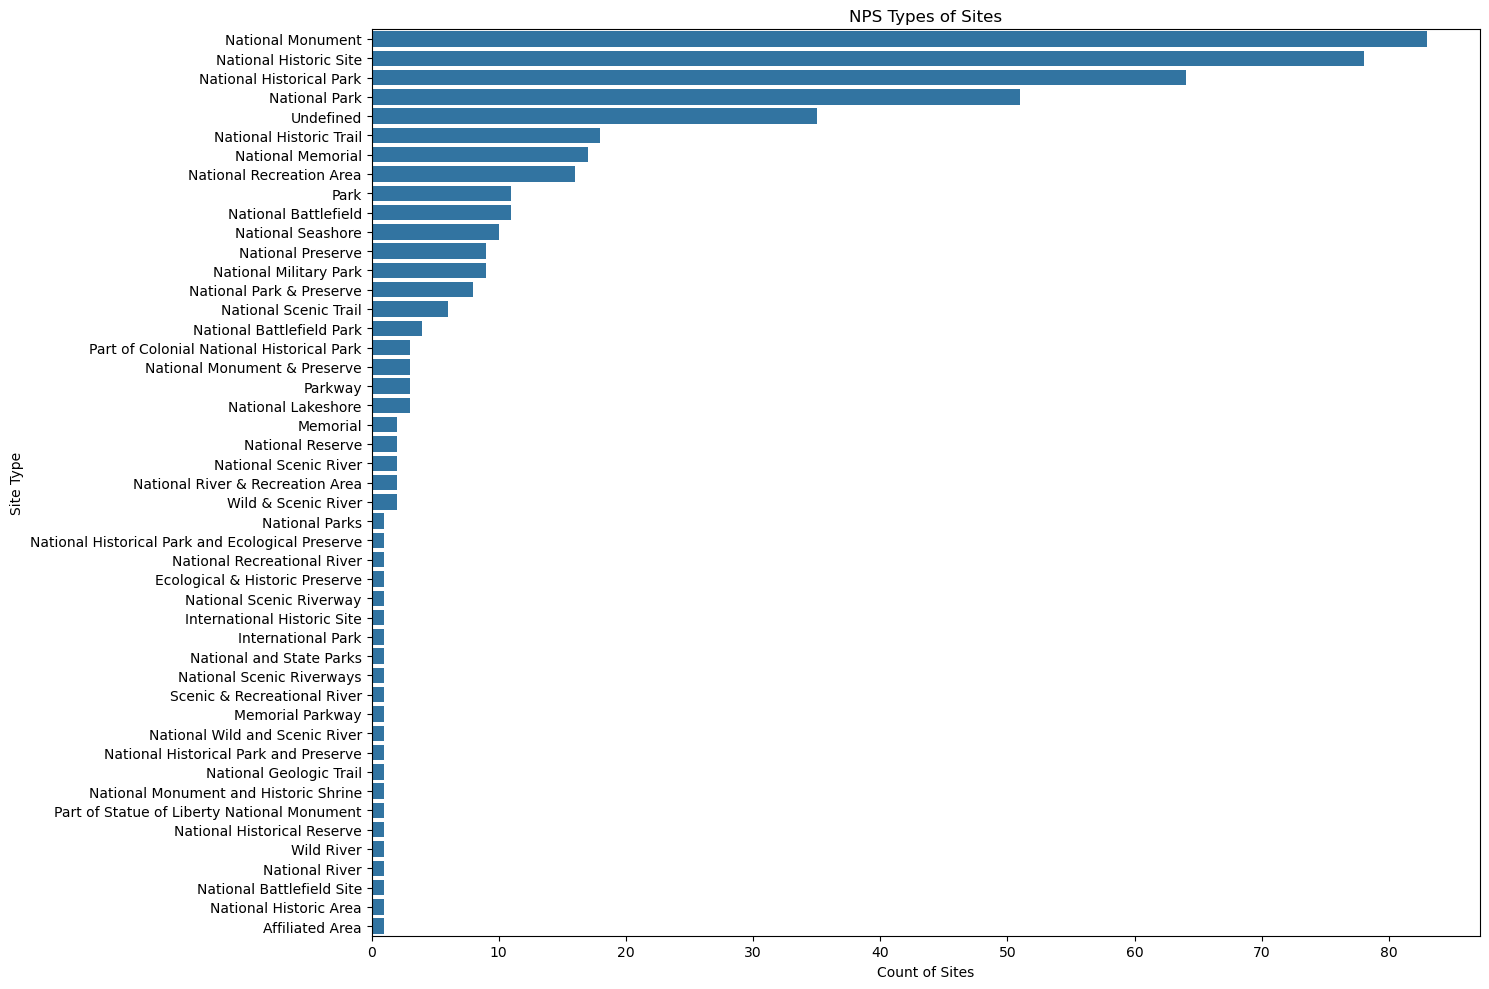

In [18]:
# Count of number of sites that fall under each designation (type of site)
plt.figure(figsize=(15, 10))#
sns.countplot(data=nps_sites, y='Designation', order = desig_desc_order)
plt.title(f'NPS Types of Sites')
plt.ylabel('Site Type')
plt.xlabel('Count of Sites')
plt.subplots_adjust(left=0.3)
plt.tight_layout()

plt.show(block=False)


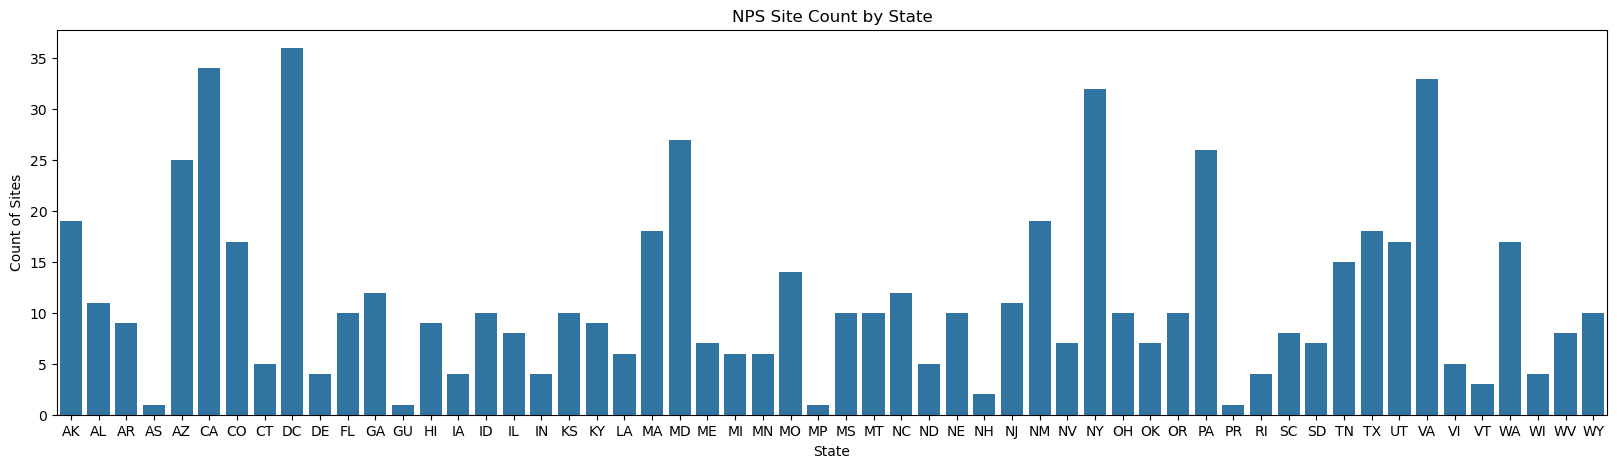

In [19]:
# Count of sites in each state
plt.figure(figsize=(20, 5))
sns.countplot(data=nps_sites_state, x='State Abb', order = state_abb_alpha)
plt.title(f'NPS Site Count by State')
plt.xlabel('State')
plt.ylabel('Count of Sites')
plt.show()

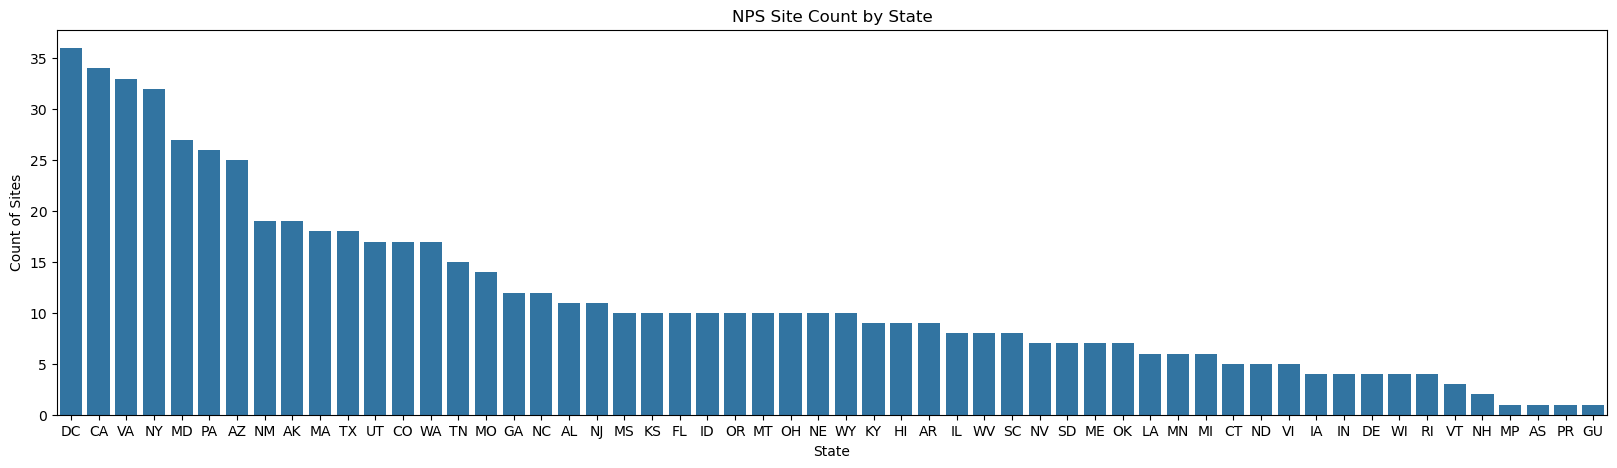

In [20]:
# Count of sites in each state
plt.figure(figsize=(20, 5))
sns.countplot(data=nps_sites_state, x='State Abb', order = state_desc_order)
plt.title(f'NPS Site Count by State')
plt.xlabel('State')
plt.ylabel('Count of Sites')
plt.show()

### NPS Visitor Data

In [21]:
# Visitation Data

visit_file_1 = "Data/Annual Visitation By Park (1979-1985).csv"

visit_1_load = pd.read_csv(visit_file_1)

#visit_1_load.head(10)

visit_1_load.columns = visit_1_load.iloc[5]

visit_1_load = visit_1_load.iloc[6:].reset_index(drop = True)

visit_1 = visit_1_load.drop(visit_1_load.columns[[0,9,10,11]], axis=1)

#visit_1.head(10)

# Convert from pivot table to flat table format

visit_1_fl = visit_1.set_index('Park Name').stack().reset_index()

visit_1_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_1_fl.head(10)

In [22]:
visit_file_2 = "Data/Annual Visitation By Park (1986-2006).csv"

visit_2_load = pd.read_csv(visit_file_2)

#visit_2_load.head(10)

visit_2_load.columns = visit_2_load.iloc[5]

visit_2_load = visit_2_load.iloc[6:].reset_index(drop = True)

#visit_2_load.head(10)

visit_2 = visit_2_load.drop(visit_2_load.columns[[0,11,12,24]], axis=1)

#visit_2.head(10)

# Convert from pivot table to flat table format

visit_2_fl = visit_2.set_index('Park Name').stack().reset_index()

visit_2_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_2_fl.head()

In [23]:
visit_file_3 = "Data/Annual Visitation By Park (2006-2025).csv"

visit_3_load = pd.read_csv(visit_file_3)

#visit_3_load.head(10)

visit_3_load.columns = visit_3_load.iloc[5]

visit_3_load = visit_3_load.iloc[6:].reset_index(drop = True)

#visit_3_load.head(10)

visit_3 = visit_3_load.drop(visit_3_load.columns[[0,11,12,24]], axis=1)

#visit_3.head(10)

# Convert from pivot table to flat table format

visit_3_fl = visit_3.set_index('Park Name').stack().reset_index()

visit_3_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_3_fl.head()

In [24]:
# Concatenate Visitor Totals from Tables

visitors = pd.concat([visit_1_fl, visit_2_fl, visit_3_fl], ignore_index=True)

visitors = visitors.sort_values(by=['Park Name','Year'])

visitors.head(20)

#print(visitors.shape)

,Park Name,Year,Visitors
0,Abraham Lincoln Birthplace NHP,1979,"271,231"
1,Abraham Lincoln Birthplace NHP,1980,"239,074"
2,Abraham Lincoln Birthplace NHP,1981,"252,245"
3,Abraham Lincoln Birthplace NHP,1982,"318,707"
4,Abraham Lincoln Birthplace NHP,1983,"256,126"
5,Abraham Lincoln Birthplace NHP,1984,"258,023"
6,Abraham Lincoln Birthplace NHP,1985,"264,905"
1982,Abraham Lincoln Birthplace NHP,1986,"280,620"
1983,Abraham Lincoln Birthplace NHP,1987,"292,825"
1984,Abraham Lincoln Birthplace NHP,1988,"288,324"


In [25]:
# Remove any rows without park name
visitors.dropna(subset = ['Park Name'], inplace = True)

#print(visitors.shape)

# Convert numbers strings to numbers
visitors['Visitors'] = visitors['Visitors'].str.replace(",","")

visitors['Visitors'] = pd.to_numeric(visitors['Visitors'])
visitors['Year'] = pd.to_numeric(visitors['Year'])

#visitors['Visitors'].dtype


In [26]:
# Scale visitor numbers

vis_max = max(visitors['Visitors'])

visitors['Visitors Scaled'] = visitors['Visitors']/vis_max

#visitors.head(20)


In [27]:
# Replace NA values with 0
visitors['Visitors'] = visitors['Visitors'].fillna(0)
visitors['Visitors Scaled'] = visitors['Visitors Scaled'].fillna(0)

visitors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16095 entries, 0 to 16094
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Park Name        16095 non-null  object 
 1   Year             16095 non-null  int64  
 2   Visitors         16095 non-null  int64  
 3   Visitors Scaled  16095 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 628.7+ KB


In [28]:
# Check for NA values
visitors[visitors.isna().any(axis=1)]


,Park Name,Year,Visitors,Visitors Scaled


In [29]:
# Import list of Site Abbreviations

visit_abb_file = "Data/Visitor_Sites_Codes.csv"

visitor_park_abb_load = pd.read_csv(visit_abb_file)

#visitor_park_abb_load.head()

visitor_park_abb = visitor_park_abb_load[['Park Name','Park_Code']]

#visitor_park_abb.head()

In [30]:
# Join site abbreviations to data frame

visitors = pd.merge(visitors, visitor_park_abb, on='Park Name', how='left')

visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code
0,Abraham Lincoln Birthplace NHP,1979,271231,0.012461,ABLI
1,Abraham Lincoln Birthplace NHP,1980,239074,0.010983,ABLI
2,Abraham Lincoln Birthplace NHP,1981,252245,0.011588,ABLI
3,Abraham Lincoln Birthplace NHP,1982,318707,0.014642,ABLI
4,Abraham Lincoln Birthplace NHP,1983,256126,0.011767,ABLI


In [31]:
visitors['Code_Year'] = visitors['Park_Code'] + '-' + visitors['Year'].astype(str)

visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year
0,Abraham Lincoln Birthplace NHP,1979,271231,0.012461,ABLI,ABLI-1979
1,Abraham Lincoln Birthplace NHP,1980,239074,0.010983,ABLI,ABLI-1980
2,Abraham Lincoln Birthplace NHP,1981,252245,0.011588,ABLI,ABLI-1981
3,Abraham Lincoln Birthplace NHP,1982,318707,0.014642,ABLI,ABLI-1982
4,Abraham Lincoln Birthplace NHP,1983,256126,0.011767,ABLI,ABLI-1983


In [32]:
visitors.describe()

,Year,Visitors,Visitors Scaled
count,16095.000000,1.609500e+04,16095.000000
mean,2003.394346,8.044333e+05,0.036956
std,13.411169,1.781894e+06,0.081862
min,1979.000000,0.000000e+00,0.000000
25%,1992.000000,5.174150e+04,0.002377
50%,2004.000000,2.053870e+05,0.009436
75%,2015.000000,7.563200e+05,0.034746
max,2025.000000,2.176718e+07,1.000000


In [33]:
# Export list of parks for mapping to NPS Unit Codes
#visitors.head()
#visitparklist = visitors['Park Name']
#visitparklist = visitparklist.drop_duplicates().sort_values()
#visitparklist.to_csv('visitparklist.csv')

In [34]:
# Total visitors by year
visitors_year = visitors.groupby('Year')['Visitors'].sum().reset_index()
#visitors_year.head(10)

In [35]:
# Top 10 visitor Parks / Years
visit_top10 = visitors.nlargest(10,'Visitors')
print(visit_top10)

            Park Name  Year  Visitors  Visitors Scaled Park_Code  Code_Year
6563  Golden Gate NRA  1987  21767176         1.000000      GOGA  GOGA-1987
6564  Golden Gate NRA  1988  21759271         0.999637      GOGA  GOGA-1988
6562  Golden Gate NRA  1986  21582368         0.991510      GOGA  GOGA-1986
1415  Blue Ridge PKWY  2002  21538760         0.989506      BLRI  BLRI-2002
6557  Golden Gate NRA  1981  20279789         0.931668      GOGA  GOGA-1981
1401  Blue Ridge PKWY  1988  20002975         0.918951      BLRI  BLRI-1988
1414  Blue Ridge PKWY  2001  19969587         0.917417      BLRI  BLRI-2001
6558  Golden Gate NRA  1982  19897389         0.914101      GOGA  GOGA-1982
1412  Blue Ridge PKWY  1999  19836842         0.911319      BLRI  BLRI-1999
1413  Blue Ridge PKWY  2000  19153081         0.879907      BLRI  BLRI-2000


In [36]:
# Top 10 visited Parks in 2025
visit_2025_top10 = visitors[visitors['Year']==2025].nlargest(10,'Visitors')
print(visit_2025_top10)

                        Park Name  Year  Visitors  Visitors Scaled Park_Code  \
1438              Blue Ridge PKWY  2025  16533753         0.759573      BLRI   
6601              Golden Gate NRA  2025  15748676         0.723506      GOGA   
7000     Great Smoky Mountains NP  2025  11527939         0.529602      GRSM   
10742          Natchez Trace PKWY  2025   7994783         0.367286      NATR   
9579                  Lincoln MEM  2025   7743295         0.355733      LINC   
6051                  Gateway NRA  2025   7696939         0.353603      GATE   
7188              Gulf Islands NS  2025   7576923         0.348089      GUIS   
6319   George Washington MEM PKWY  2025   6732932         0.309316      GWMP   
575               Appalachian NST  2025   6215118         0.285527      APPA   
9203                Lake Mead NRA  2025   6135586         0.281873      LAKE   

       Code_Year  
1438   BLRI-2025  
6601   GOGA-2025  
7000   GRSM-2025  
10742  NATR-2025  
9579   LINC-2025  
6051 

In [37]:
# Add designation to data frame for additional filtering
# designation list
nps_sites_desiglist = nps_sites[['Park_Code','Designation']]

visitor_park_wdesig = pd.merge(visitor_park_abb,nps_sites_desiglist,on = 'Park_Code', how = 'left')

visitor_park_wdesig.drop(columns=['Park Name'], inplace=True)

visitor_park_wdesig.head()

,Park_Code,Designation
0,ABLI,National Historical Park
1,ACAD,National Park
2,ADAM,National Historical Park
3,AFBG,National Monument
4,AGFO,National Monument


In [38]:
visitors = pd.merge(visitors, visitor_park_wdesig,on = 'Park_Code', how = 'left')
visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,Designation
0,Abraham Lincoln Birthplace NHP,1979,271231,0.012461,ABLI,ABLI-1979,National Historical Park
1,Abraham Lincoln Birthplace NHP,1980,239074,0.010983,ABLI,ABLI-1980,National Historical Park
2,Abraham Lincoln Birthplace NHP,1981,252245,0.011588,ABLI,ABLI-1981,National Historical Park
3,Abraham Lincoln Birthplace NHP,1982,318707,0.014642,ABLI,ABLI-1982,National Historical Park
4,Abraham Lincoln Birthplace NHP,1983,256126,0.011767,ABLI,ABLI-1983,National Historical Park


In [39]:
natlpark_2025_prep = visitors[(visitors['Year'] == 2025) &  (visitors['Designation']=='National Park')]
visit_2025_top10_natlpk = natlpark_2025_prep.nlargest(10,'Visitors')
visit_2025_top10_natlpk

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,Designation
7094,Great Smoky Mountains NP,2025,11527939,0.529602,GRSM,GRSM-2025,National Park
16677,Zion NP,2025,4984525,0.228993,ZION,ZION-2025,National Park
16539,Yellowstone NP,2025,4762988,0.218815,YELL,YELL-2025,National Park
6765,Grand Canyon NP,2025,4430653,0.203547,GRCA,GRCA-2025,National Park
16586,Yosemite NP,2025,4278413,0.196553,YOSE,YOSE-2025,National Park
13113,Rocky Mountain NP,2025,4171431,0.191639,ROMO,ROMO-2025,National Park
93,Acadia NP,2025,4079318,0.187407,ACAD,ACAD-2025,National Park
6905,Grand Teton NP,2025,3800648,0.174605,GRTE,GRTE-2025,National Park
6906,Grand Teton NP,2025,3800648,0.174605,GRTE,GRTE-2025,National Park
11728,Olympic NP,2025,3584187,0.164660,OLYM,OLYM-2025,National Park


### NPS Visitor Data Visualizations

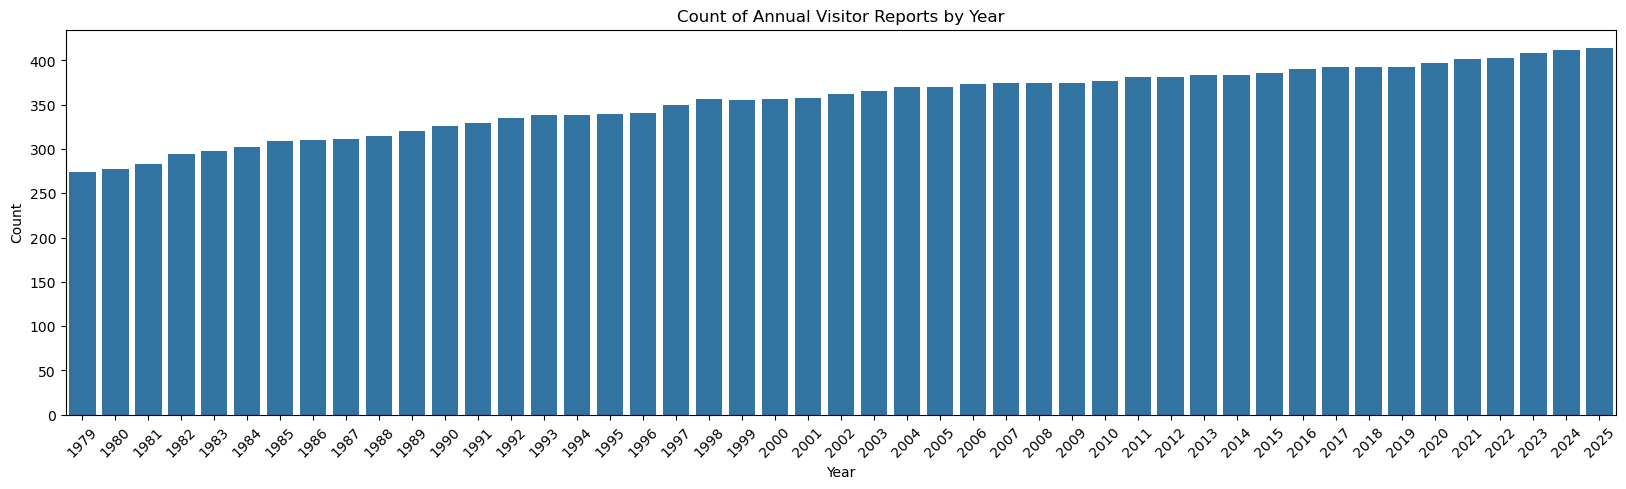

In [40]:
# Plot Number of Site Annual Visitor Reports by Year
plt.figure(figsize=(20, 5))
sns.countplot(data=visitors, x='Year')
plt.title(f'Count of Annual Visitor Reports by Year')
plt.xlabel('Year')
plt.ylabel('Count')
#plt.bar_label
plt.xticks(rotation=45)
plt.show()


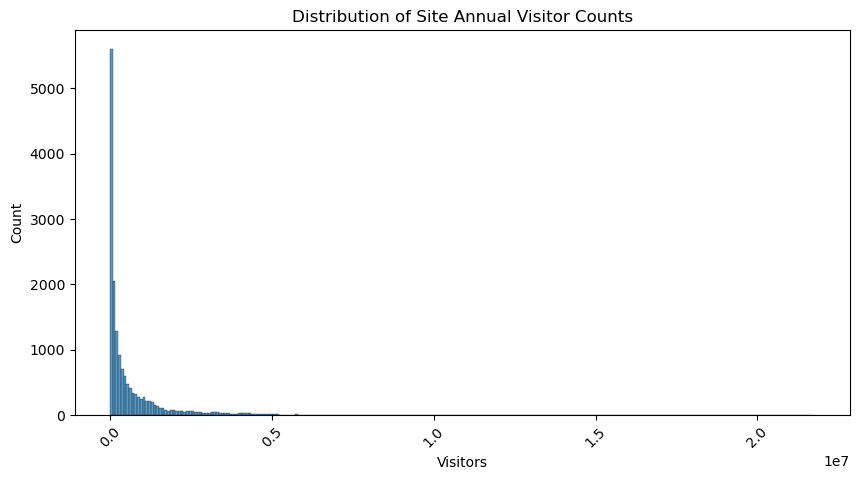

In [41]:
# Plot Distribution of Visitor Counts
plt.figure(figsize=(10, 5))
sns.histplot(data=visitors, x='Visitors')
plt.title(f'Distribution of Site Annual Visitor Counts')
plt.xlabel('Visitors')
plt.ylabel('Count')
#plt.bar_label
plt.xticks(rotation=45)
plt.show()


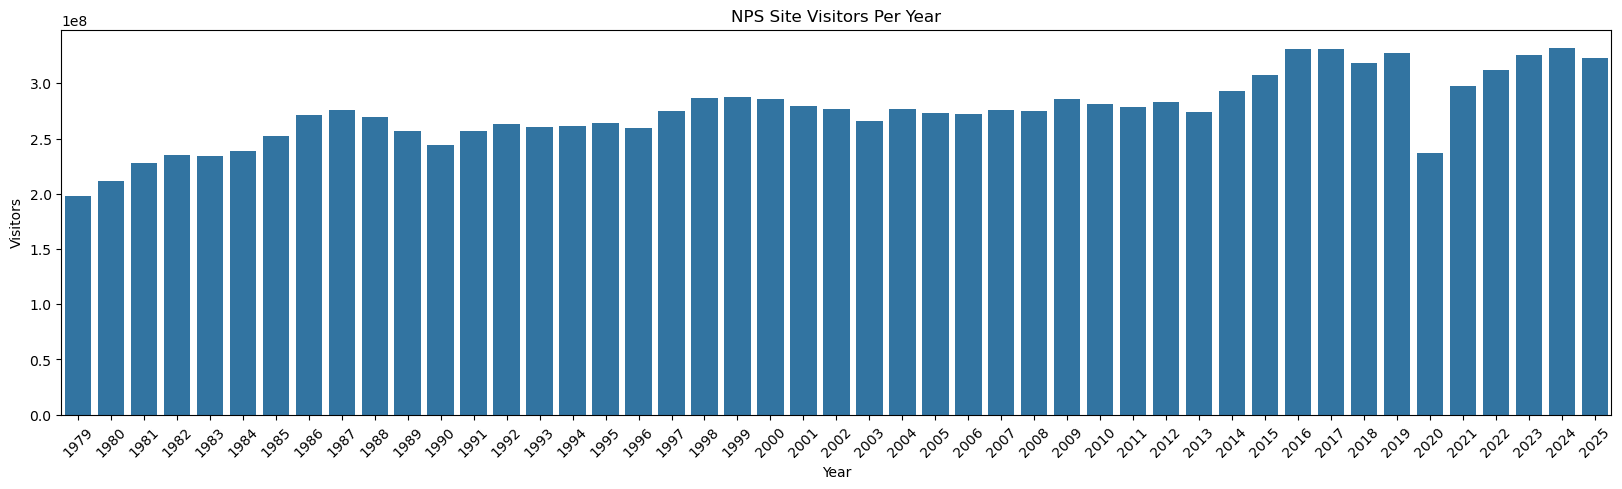

In [42]:
# Sum of National Park Visitors by Year
plt.figure(figsize=(20, 5))
sns.barplot(data=visitors_year, x='Year',y = 'Visitors')
plt.title(f'NPS Site Visitors Per Year')
plt.xlabel('Year')
plt.ylabel('Visitors')
plt.xticks(rotation=45)
plt.show()

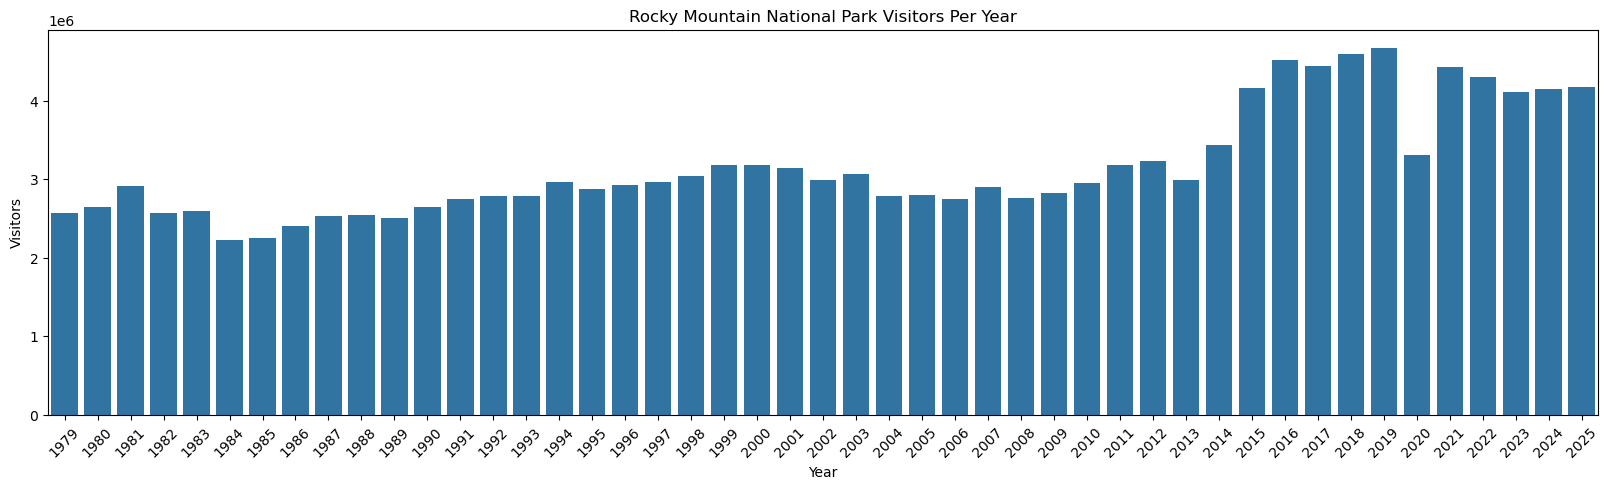

In [43]:
rmnp_visitors = visitors[visitors['Park_Code'] == 'ROMO']

# Sum of National Park Visitors by Year at Rocky Mtn Natl Park
plt.figure(figsize=(20, 5))
sns.barplot(data=rmnp_visitors, x='Year',y = 'Visitors')
plt.title(f'Rocky Mountain National Park Visitors Per Year')
plt.xlabel('Year')
plt.ylabel('Visitors')
plt.xticks(rotation=45)
plt.show()

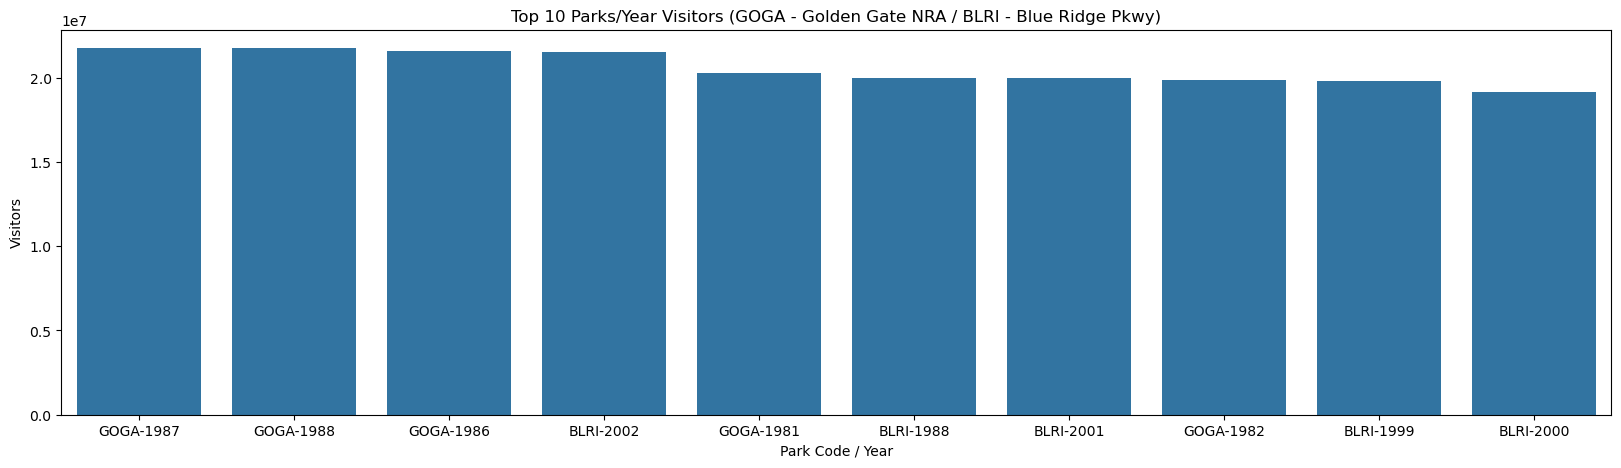

In [44]:
# Top 10 Visisted Park / Year
plt.figure(figsize=(20, 5))
sns.barplot(data = visit_top10, x='Code_Year',y = 'Visitors')
plt.title(f'Top 10 Parks/Year Visitors (GOGA - Golden Gate NRA / BLRI - Blue Ridge Pkwy)')
plt.xlabel('Park Code / Year')
plt.ylabel('Visitors')
#plt.xticks(rotation=45)
plt.show()

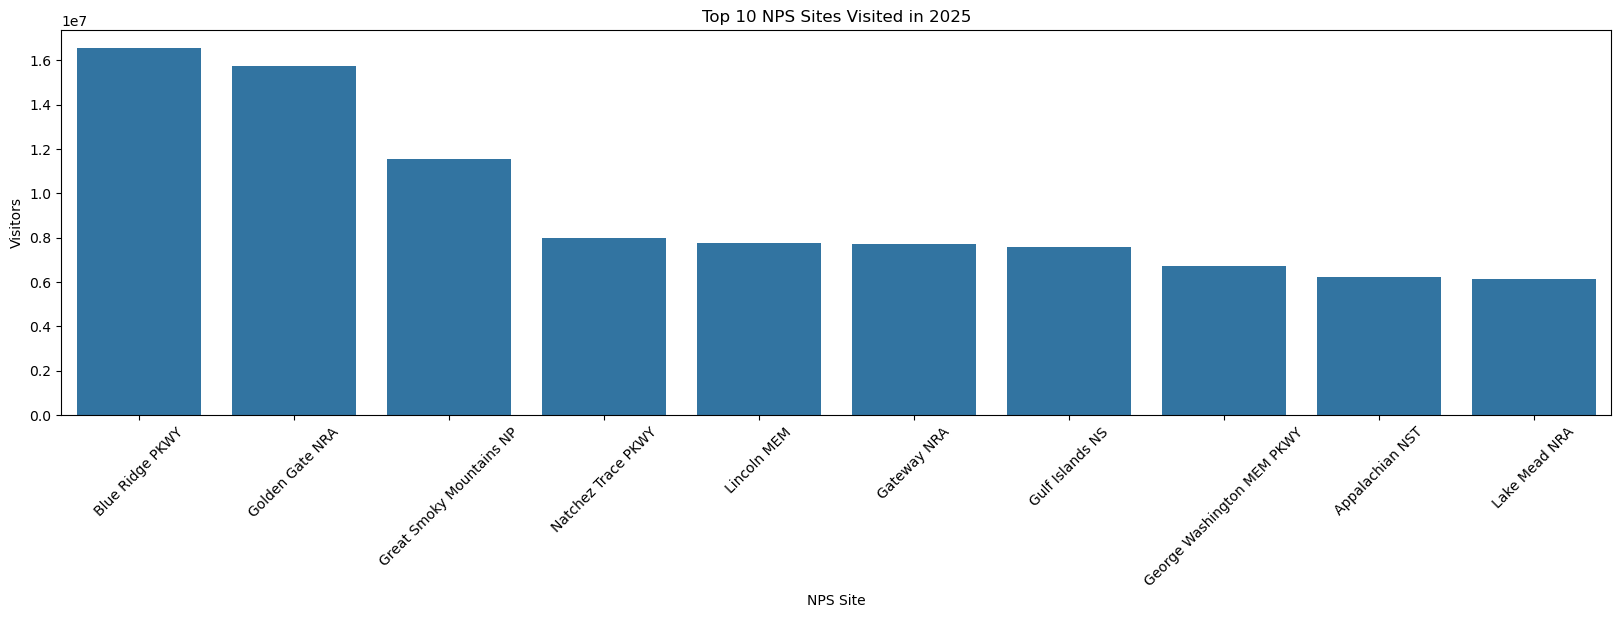

In [45]:
# Top 10 Visisted Parks in 2025
plt.figure(figsize=(20, 5))
sns.barplot(data = visit_2025_top10, x='Park Name',y = 'Visitors')
plt.title(f'Top 10 NPS Sites Visited in 2025')
plt.xlabel('NPS Site')
plt.ylabel('Visitors')
plt.xticks(rotation=45)
plt.show()

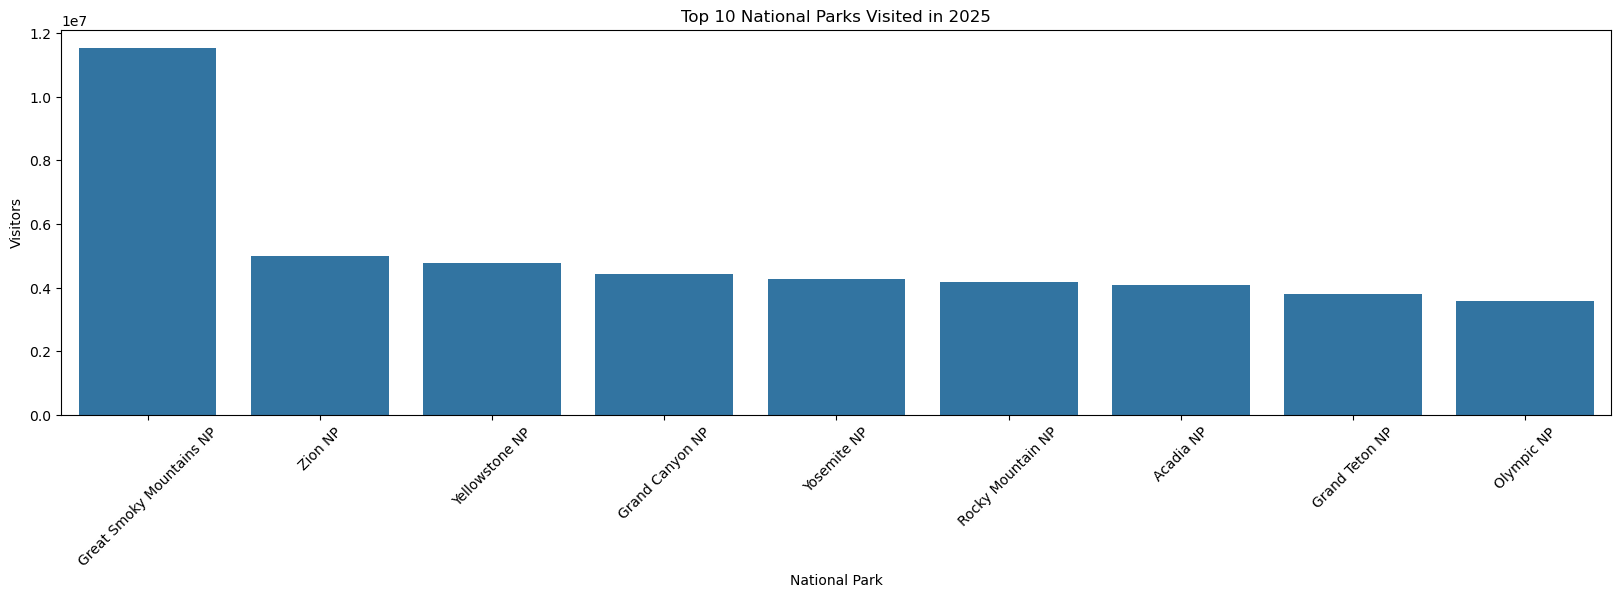

In [46]:
# Top 10 Visisted National Parks in 2025
plt.figure(figsize=(20, 5))
sns.barplot(data = visit_2025_top10_natlpk, x='Park Name',y = 'Visitors')
plt.title(f'Top 10 National Parks Visited in 2025')
plt.xlabel('National Park')
plt.ylabel('Visitors')
plt.xticks(rotation=45)
plt.show()

### NPS Traffic Data

In [47]:
# Traffic Data

traffic_file_1 = "Data/Query Builder for Traffic Counts (1985-1989).csv"

traffic_file_2 = "Data/Query Builder for Traffic Counts (1990-1999).csv"

traffic_file_3 = "Data/Query Builder for Traffic Counts (2000-2009).csv"

traffic_file_4 = "Data/Query Builder for Traffic Counts (2010-2019).csv"

traffic_file_5 = "Data/Query Builder for Traffic Counts (2020-2025).csv"


In [48]:
#
traffic_1_load = pd.read_csv(traffic_file_1)

#traffic_1_load.head(10)

traffic_1_load.columns = traffic_1_load.iloc[1]

traffic_1_load = traffic_1_load.iloc[2:].reset_index(drop = True)

traffic_1 = traffic_1_load[[]]

#traffic_1_load.head(10)

#traffic_1_load['Traffic Count'].dtype

traffic_1_load['Traffic Count'] = traffic_1_load['Traffic Count'].str.replace(",","")

#traffic_1_load.head()

traffic_1_load['Traffic Count'] = pd.to_numeric(traffic_1_load['Traffic Count'])

#traffic_1_load['Traffic Count'].dtype

#traffic_1_load.head()

traffic_1 = traffic_1_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

traffic_1

,Unit Code,Year,Traffic Count
0,BLRI,1988,3721649
1,BLRI,1989,3891985
2,YOSE,1985,1571341
3,YOSE,1986,1370764
4,YOSE,1987,1621929
5,YOSE,1988,1625643
6,YOSE,1989,1636968


In [49]:
#

traffic_2_load = pd.read_csv(traffic_file_2)

#traffic_2_load.head(10)

traffic_2_load.columns = traffic_2_load.iloc[1]

traffic_2_load = traffic_2_load.iloc[2:].reset_index(drop = True)

traffic_2 = traffic_2_load[[]]

#traffic_2_load.head(10)

#traffic_2_load['Traffic Count'].dtype

traffic_2_load['Traffic Count'] = traffic_2_load['Traffic Count'].str.replace(",","")

#traffic_2_load.head()

traffic_2_load['Traffic Count'] = pd.to_numeric(traffic_2_load['Traffic Count'])

#traffic_2_load['Traffic Count'].dtype

#traffic_2_load.head()

traffic_2 = traffic_2_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_2


In [50]:
#

traffic_3_load = pd.read_csv(traffic_file_3)

#traffic_3_load.head(10)

traffic_3_load.columns = traffic_3_load.iloc[1]

traffic_3_load = traffic_3_load.iloc[2:].reset_index(drop = True)

traffic_3 = traffic_3_load[[]]

#traffic_3_load.head(10)

#traffic_3_load['Traffic Count'].dtype

traffic_3_load['Traffic Count'] = traffic_3_load['Traffic Count'].str.replace(",","")

#traffic_3_load.head()

traffic_3_load['Traffic Count'] = pd.to_numeric(traffic_3_load['Traffic Count'])

#traffic_3_load['Traffic Count'].dtype

#traffic_3_load.head()

traffic_3 = traffic_3_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_3

In [51]:
#

traffic_4_load = pd.read_csv(traffic_file_4)

#traffic_4_load.head(10)

traffic_4_load.columns = traffic_4_load.iloc[1]

traffic_4_load = traffic_4_load.iloc[2:].reset_index(drop = True)

traffic_4 = traffic_4_load[[]]

#traffic_4_load.head(10)

#traffic_4_load['Traffic Count'].dtype

traffic_4_load['Traffic Count'] = traffic_4_load['Traffic Count'].str.replace(",","")

#traffic_4_load.head()

traffic_4_load['Traffic Count'] = pd.to_numeric(traffic_4_load['Traffic Count'])

traffic_4_load['Traffic Count'].dtype

#traffic_4_load.head()

traffic_4 = traffic_4_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_4


In [52]:
#

traffic_5_load = pd.read_csv(traffic_file_5)

traffic_5_load.columns = traffic_5_load.iloc[1]

traffic_5_load = traffic_5_load.iloc[2:].reset_index(drop = True)

traffic_5 = traffic_5_load[[]]

traffic_5_load['Traffic Count'] = traffic_5_load['Traffic Count'].str.replace(",","")

#traffic_5_load.head()

traffic_5_load['Traffic Count'] = pd.to_numeric(traffic_5_load['Traffic Count'])

traffic_5 = traffic_5_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()


In [53]:
# Concatenate Traffic Totals from Tables

traffic = pd.concat([traffic_1,traffic_2,traffic_3,traffic_4,traffic_5], ignore_index=True)

traffic['Year'] = pd.to_numeric(traffic['Year'])

traffic['Code_Year'] = traffic['Unit Code'] + '-' + traffic['Year'].astype(str)

traffic_max = max(traffic['Traffic Count'])

traffic['Traffic Count Scaled'] = traffic['Traffic Count']/traffic_max

print(traffic.head(20))

print(traffic.shape)

   Unit Code  Year  Traffic Count  Code_Year  Traffic Count Scaled
0       BLRI  1988      3721649.0  BLRI-1988              0.106528
1       BLRI  1989      3891985.0  BLRI-1989              0.111404
2       YOSE  1985      1571341.0  YOSE-1985              0.044978
3       YOSE  1986      1370764.0  YOSE-1986              0.039237
4       YOSE  1987      1621929.0  YOSE-1987              0.046426
5       YOSE  1988      1625643.0  YOSE-1988              0.046532
6       YOSE  1989      1636968.0  YOSE-1989              0.046857
7       ABLI  1993        84248.0  ABLI-1993              0.002412
8       ABLI  1994        78659.0  ABLI-1994              0.002252
9       ABLI  1995        75253.0  ABLI-1995              0.002154
10      ABLI  1996        69894.0  ABLI-1996              0.002001
11      ABLI  1997        73586.0  ABLI-1997              0.002106
12      ABLI  1998        70560.0  ABLI-1998              0.002020
13      ABLI  1999        70798.0  ABLI-1999              0.00

In [54]:
# Add designation to data frame for additional filtering
# designation list
#nps_sites_desiglist = nps_sites[['Park_Code','Designation']]

traffic = pd.merge(traffic,nps_sites_desiglist,left_on = 'Unit Code', right_on = 'Park_Code', how = 'left')

traffic.drop(columns=['Park_Code'], inplace=True)



In [55]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled
count,6841.000000,6.841000e+03,6841.000000
mean,2009.117673,9.407529e+05,0.026928
std,9.762653,3.139628e+06,0.089869
min,1985.000000,-2.633245e+06,-0.075374
25%,2001.000000,4.944400e+04,0.001415
50%,2009.000000,1.731410e+05,0.004956
75%,2018.000000,4.767610e+05,0.013647
max,2025.000000,3.493576e+07,1.000000


In [56]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841 entries, 0 to 6840
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unit Code             6841 non-null   object 
 1   Year                  6841 non-null   int64  
 2   Traffic Count         6841 non-null   float64
 3   Code_Year             6841 non-null   object 
 4   Traffic Count Scaled  6841 non-null   float64
 5   Designation           6605 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 320.8+ KB


In [57]:
traffic_year = traffic.groupby('Year')['Traffic Count'].sum().reset_index()
traffic_year.head(10)

,Year,Traffic Count
0,1985,1571341.0
1,1986,1370764.0
2,1987,1621929.0
3,1988,5347292.0
4,1989,5528953.0
5,1990,6397101.0
6,1991,45748672.0
7,1992,68554030.0
8,1993,108900731.0
9,1994,156668265.0


### NPS Traffic Data Visualizations

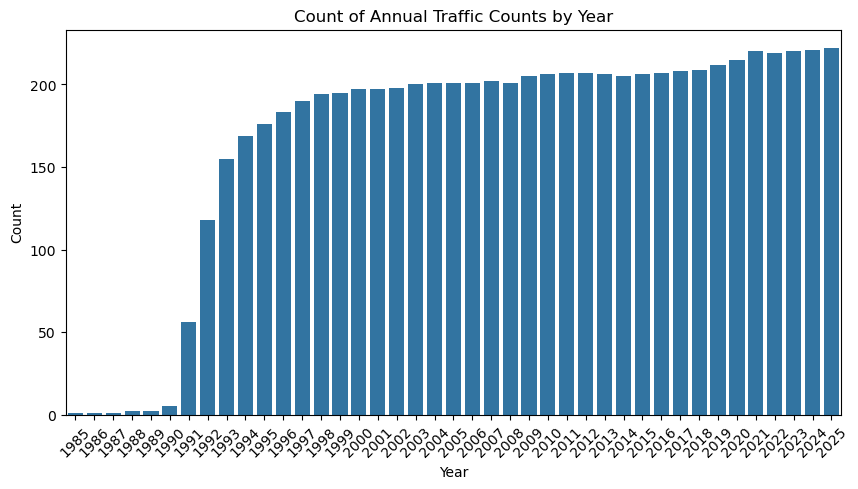

In [58]:
plt.figure(figsize=(10, 5))
sns.countplot(data=traffic, x='Year')
plt.title(f'Count of Annual Traffic Counts by Year')
plt.xlabel('Year')
plt.ylabel('Count')
#plt.bar_label
plt.xticks(rotation=45)
plt.show()


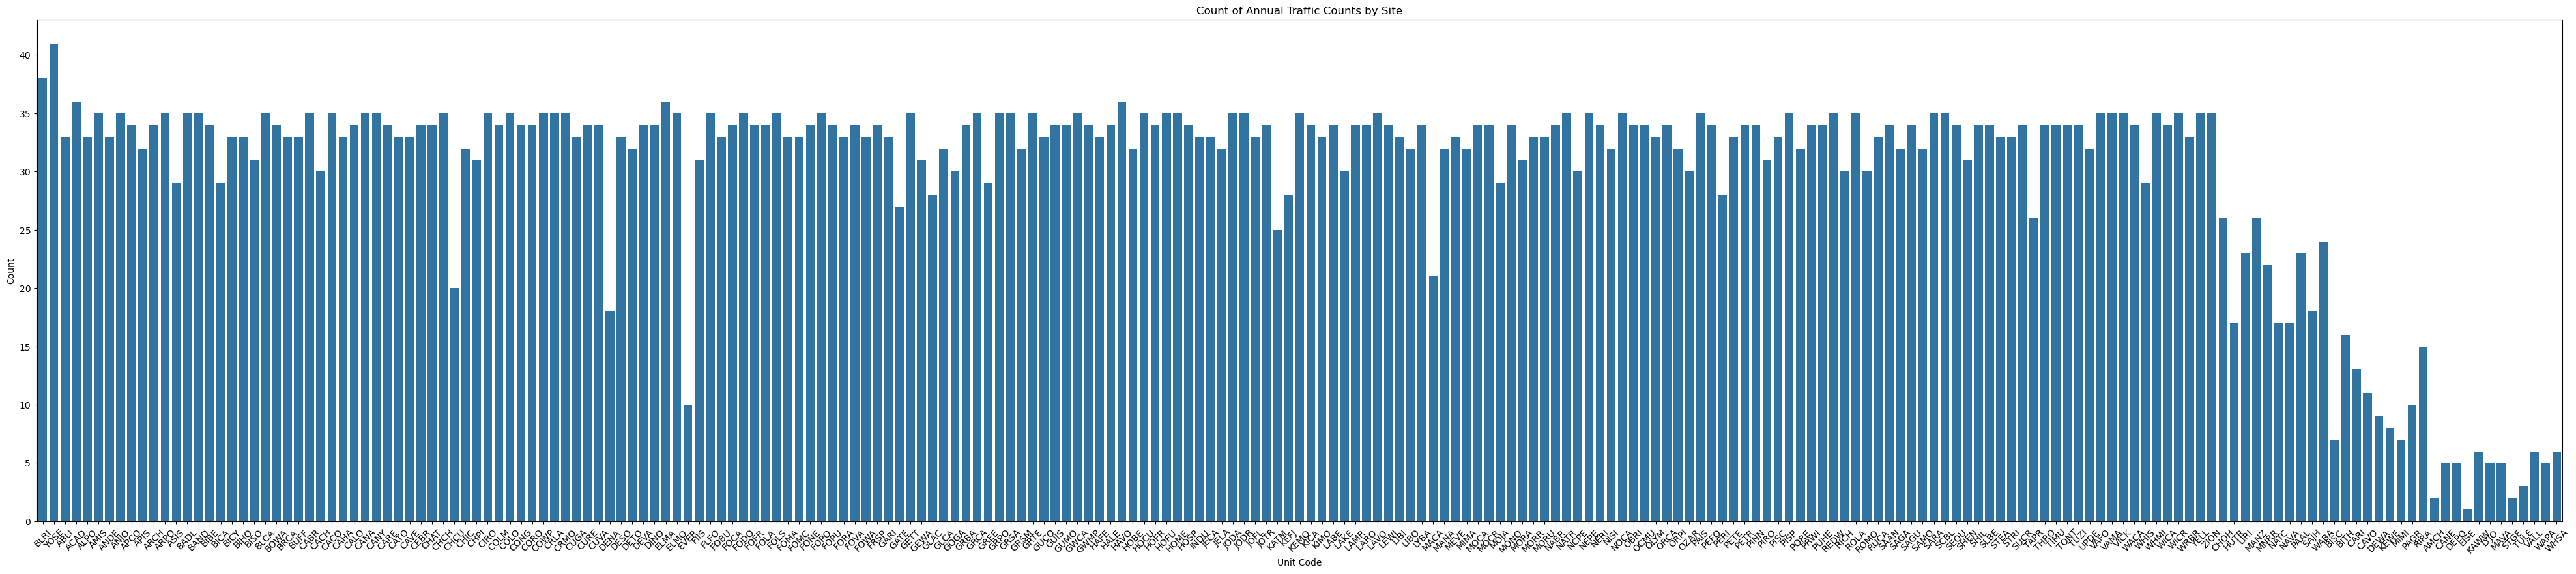

In [59]:
plt.figure(figsize=(50, 10))
sns.countplot(data=traffic, x='Unit Code')
plt.title(f'Count of Annual Traffic Counts by Site')
plt.xlabel('Unit Code')
plt.ylabel('Count')
#plt.bar_label
plt.xticks(rotation=45)
plt.show()

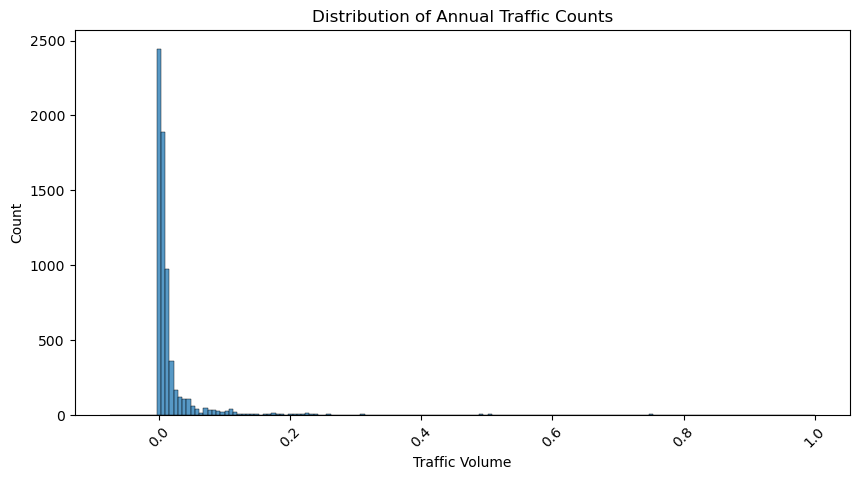

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(data=traffic, x='Traffic Count Scaled')
plt.title(f'Distribution of Annual Traffic Counts')
plt.xlabel('Traffic Volume')
plt.ylabel('Count')
#plt.bar_label
plt.xticks(rotation=45)
plt.show()


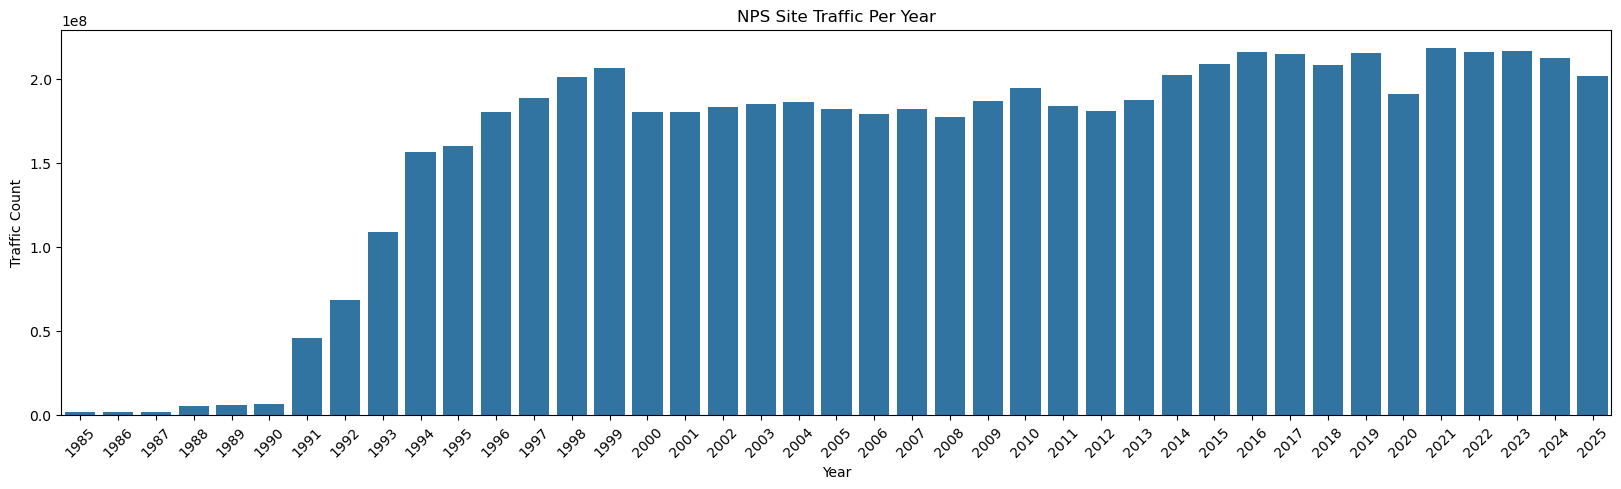

In [61]:
# Sum of National Park Traffic by Year
plt.figure(figsize=(20, 5))
sns.barplot(data=traffic_year, x='Year',y = 'Traffic Count')
plt.title(f'NPS Site Traffic Per Year')
plt.xlabel('Year')
plt.ylabel('Traffic Count')
plt.xticks(rotation=45)
plt.show()

### CEI Data

In [62]:
cei_file_us = "Data/CEI_ContigUS.csv"

cei_us_load = pd.read_csv(cei_file_us)

cei_us_load.columns = cei_us_load.iloc[0]

cei_us_load = cei_us_load.iloc[1:].reset_index(drop = False)

cei_us_load = cei_us_load.rename(columns={'Date': '','index': 'Year'})

cei_us_load['Year'] = pd.to_numeric(cei_us_load['Year'])

cei_us_load['Percentage Area'] = pd.to_numeric(cei_us_load['Percentage Area'])/100

cei_us = cei_us_load

cei_us.head(10)

Date,Year,Percentage Area
0,1910,0.2292
1,1911,0.2416
2,1912,0.3592
3,1913,0.1926
4,1914,0.1990
5,1915,0.2138
6,1916,0.2898
7,1917,0.3394
8,1918,0.1168
9,1919,0.2014


In [63]:
cei_file_us_trop = "Data/CEI_ContigUS_wTropCycl.csv"

cei_ust_load = pd.read_csv(cei_file_us)

cei_ust_load.columns = cei_ust_load.iloc[0]

cei_ust_load = cei_ust_load.iloc[1:].reset_index(drop = False)

cei_ust_load = cei_ust_load.rename(columns={'Date': '','index': 'Year'})

cei_ust_load['Year'] = pd.to_numeric(cei_ust_load['Year'])

cei_ust_load['Percentage Area'] = pd.to_numeric(cei_ust_load['Percentage Area'])/100

cei_us_trop = cei_ust_load

#cei_us_trop.head(10)

In [64]:
# List of CE Regions and assigned states

cei_regions_file = "Data/CEI_Regions_States.csv"

cei_reg_load = pd.read_csv(cei_regions_file)

cei_reg_load.head(10)

,CEI Region,State,State Abb
0,Northwest,Washington,WA
1,Northwest,Oregon,OR
2,Northwest,Idaho,ID
3,West,California,CA
4,West,Nevada,NV
5,Southwest,Utah,UT
6,Southwest,Colorado,CO
7,Southwest,Arizona,AZ
8,Southwest,New Mexico,NM
9,Northern Rockies and Plains,Montana,MT


In [65]:
cei_file_1 = "Data/CEI_Northwest.csv"

reg_name = "Northwest"

cei_1_load = pd.read_csv(cei_file_1)

cei_1_load.columns = cei_1_load.iloc[0]

cei_1_load = cei_1_load.iloc[1:].reset_index(drop = False)

cei_1_load = cei_1_load.rename(columns={'Date': '','index': 'Year'})

cei_1_load['Region'] = reg_name

#cei_1_load.head(10)



In [66]:
cei_file_2 = "Data/CEI_Southwest.csv"

reg_name = "Southwest"

cei_2_load = pd.read_csv(cei_file_2)

cei_2_load.columns = cei_2_load.iloc[0]

cei_2_load = cei_2_load.iloc[1:].reset_index(drop = False)

cei_2_load = cei_2_load.rename(columns={'Date': '','index': 'Year'})

cei_2_load['Region'] = reg_name

#cei_2_load.head(10)

In [67]:
cei_file_3 = "Data/CEI_South.csv"

reg_name = "South"

cei_3_load = pd.read_csv(cei_file_3)

cei_3_load.columns = cei_3_load.iloc[0]

cei_3_load = cei_3_load.iloc[1:].reset_index(drop = False)

cei_3_load = cei_3_load.rename(columns={'Date': '','index': 'Year'})

cei_3_load['Region'] = reg_name

#cei_3_load.head(10)

In [68]:
cei_file_4 = "Data/CEI_Northeast.csv"

reg_name = "Northeast"

cei_4_load = pd.read_csv(cei_file_4)

cei_4_load.columns = cei_4_load.iloc[0]

cei_4_load = cei_4_load.iloc[1:].reset_index(drop = False)

cei_4_load = cei_4_load.rename(columns={'Date': '','index': 'Year'})

cei_4_load['Region'] = reg_name

#cei_4_load.head(10)

In [69]:
cei_file_5 = "Data/CEI_NorthernRockiesandPlains.csv"

reg_name = "Northern Rockies and Plains"

cei_5_load = pd.read_csv(cei_file_5)

cei_5_load.columns = cei_5_load.iloc[0]

cei_5_load = cei_5_load.iloc[1:].reset_index(drop = False)

cei_5_load = cei_5_load.rename(columns={'Date': '','index': 'Year'})

cei_5_load['Region'] = reg_name

#cei_5_load.head(10)

In [70]:
cei_file_6 = "Data/CEI_OhioValley.csv"

reg_name = "Ohio Valley"

cei_6_load = pd.read_csv(cei_file_6)

cei_6_load.columns = cei_6_load.iloc[0]

cei_6_load = cei_6_load.iloc[1:].reset_index(drop = False)

cei_6_load = cei_6_load.rename(columns={'Date': '','index': 'Year'})

cei_6_load['Region'] = reg_name

#cei_6_load.head(10)

In [71]:
cei_file_7 = "Data/CEI_UpperMidwest.csv"

reg_name = "Upper Midwest"

cei_7_load = pd.read_csv(cei_file_7)

cei_7_load.columns = cei_7_load.iloc[0]

cei_7_load = cei_7_load.iloc[1:].reset_index(drop = False)

cei_7_load = cei_7_load.rename(columns={'Date': '','index': 'Year'})

cei_7_load['Region'] = reg_name

#cei_7_load.head(10)

In [72]:
cei_file_8 = "Data/CEI_Southeast.csv"

reg_name = "Southeast"

cei_8_load = pd.read_csv(cei_file_8)

cei_8_load.columns = cei_8_load.iloc[0]

cei_8_load = cei_8_load.iloc[1:].reset_index(drop = False)

cei_8_load = cei_8_load.rename(columns={'Date': '','index': 'Year'})

cei_8_load['Region'] = reg_name

#cei_8_load.head(10)

In [73]:
cei_file_9 = "Data/CEI_West.csv"

reg_name = "West"

cei_9_load = pd.read_csv(cei_file_9)

cei_9_load.columns = cei_9_load.iloc[0]

cei_9_load = cei_9_load.iloc[1:].reset_index(drop = False)

cei_9_load = cei_9_load.rename(columns={'Date': '','index': 'Year'})

cei_9_load['Region'] = reg_name

#cei_9_load.head(10)

In [74]:
# Concatenate CEI Data from Tables

cei_data = pd.concat([cei_1_load,cei_2_load,cei_3_load,cei_4_load,cei_5_load,cei_6_load,cei_7_load,cei_8_load,cei_9_load], ignore_index=True)

cei_data['Year'] = pd.to_numeric(cei_data['Year'])
cei_data['Percentage Area'] = pd.to_numeric(cei_data['Percentage Area'])/100

cei_data.head(10)

#print(cei_data.shape)

Date,Year,Percentage Area,Region
0,1910,0.1042,Northwest
1,1911,0.3650,Northwest
2,1912,0.3418,Northwest
3,1913,0.3692,Northwest
4,1914,0.0988,Northwest
5,1915,0.0390,Northwest
6,1916,0.5424,Northwest
7,1917,0.1802,Northwest
8,1918,0.0812,Northwest
9,1919,0.4144,Northwest


In [75]:
cei_data.describe()

Date,Year,Percentage Area
count,1044.00000,1044.000000
mean,1967.50000,0.200182
std,33.50112,0.130637
min,1910.00000,0.000000
25%,1938.75000,0.104350
50%,1967.50000,0.167300
75%,1996.25000,0.269650
max,2025.00000,0.718600


In [76]:
cei_us_recent = cei_us[cei_us['Year']>=1980]

In [77]:
cei_data_recent = cei_data[cei_data['Year']>=1980]

### CEI Data Visualization

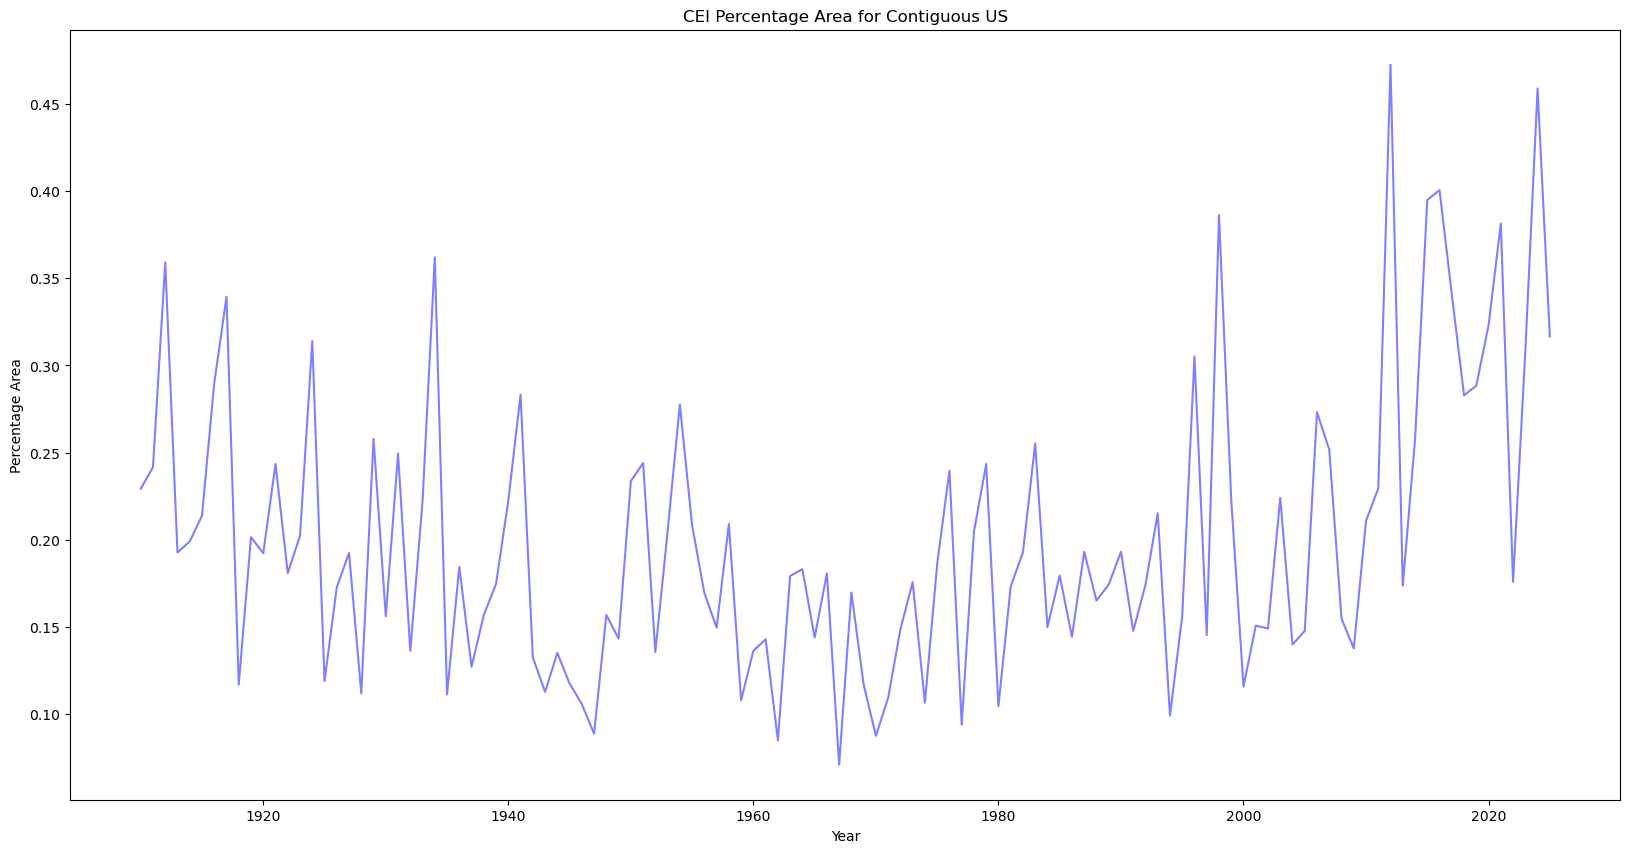

In [78]:
# CEI Contiguous US
plt.figure(figsize=(20, 10))
sns.lineplot(data=cei_us, x='Year', y='Percentage Area', color = 'blue',alpha = 0.5, linestyle = "solid")
#sns.lineplot(data=cei_us_trop, x='Year', y='Percentage Area', color = 'orange',alpha = 0.2, linestyle = "dashed")
plt.title(f'CEI Percentage Area for Contiguous US')
plt.xlabel('Year')
plt.ylabel('Percentage Area')
plt.show(block = True)

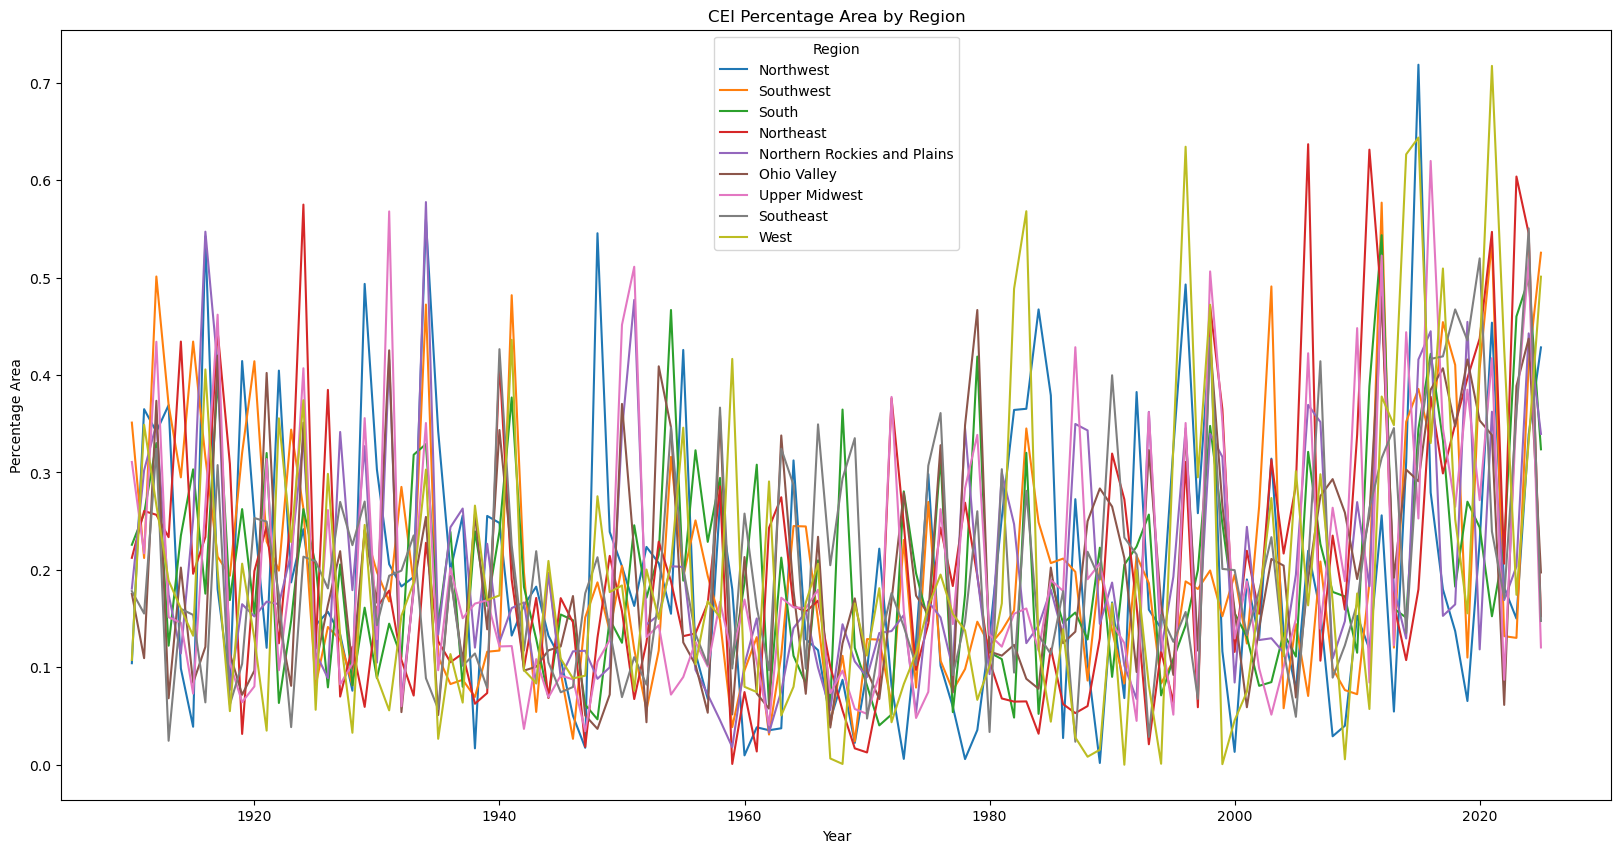

In [79]:
# CEI Time History by Region
plt.figure(figsize=(20, 10))
sns.lineplot(data=cei_data, x='Year', y='Percentage Area', hue='Region')
plt.title(f'CEI Percentage Area by Region')
plt.xlabel('Year')
plt.ylabel('Percentage Area')
plt.show()

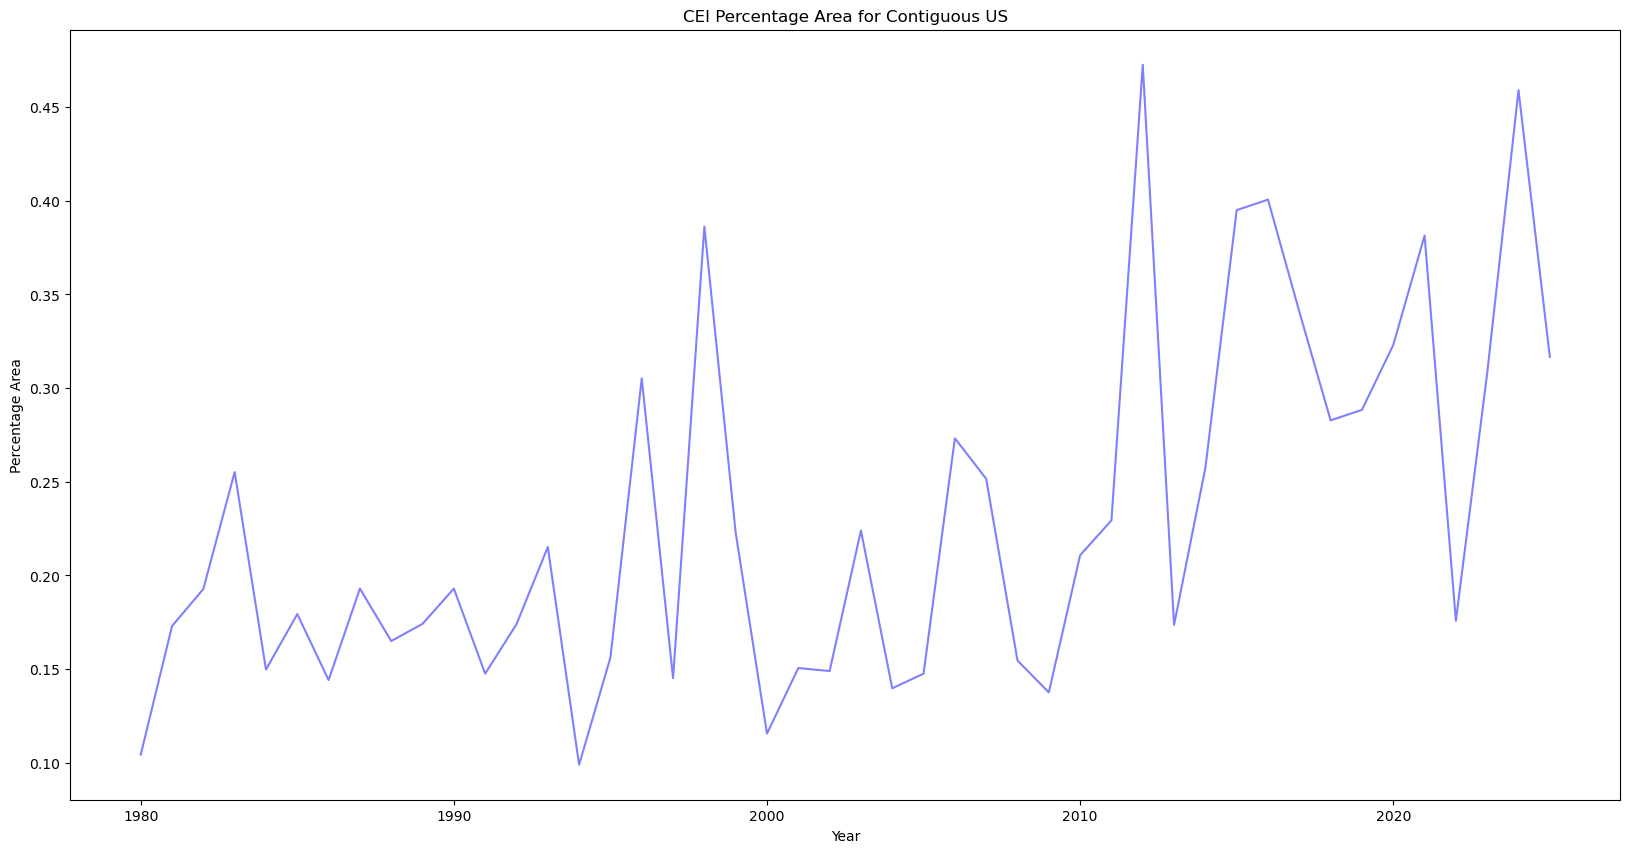

In [80]:
# CEI Contiguous US Recent History
plt.figure(figsize=(20, 10))
sns.lineplot(data=cei_us_recent, x='Year', y='Percentage Area', color = 'blue',alpha = 0.5, linestyle = "solid")
#sns.lineplot(data=cei_us_trop, x='Year', y='Percentage Area', color = 'orange',alpha = 0.2, linestyle = "dashed")
plt.title(f'CEI Percentage Area for Contiguous US')
plt.xlabel('Year')
plt.ylabel('Percentage Area')
plt.show(block = True)

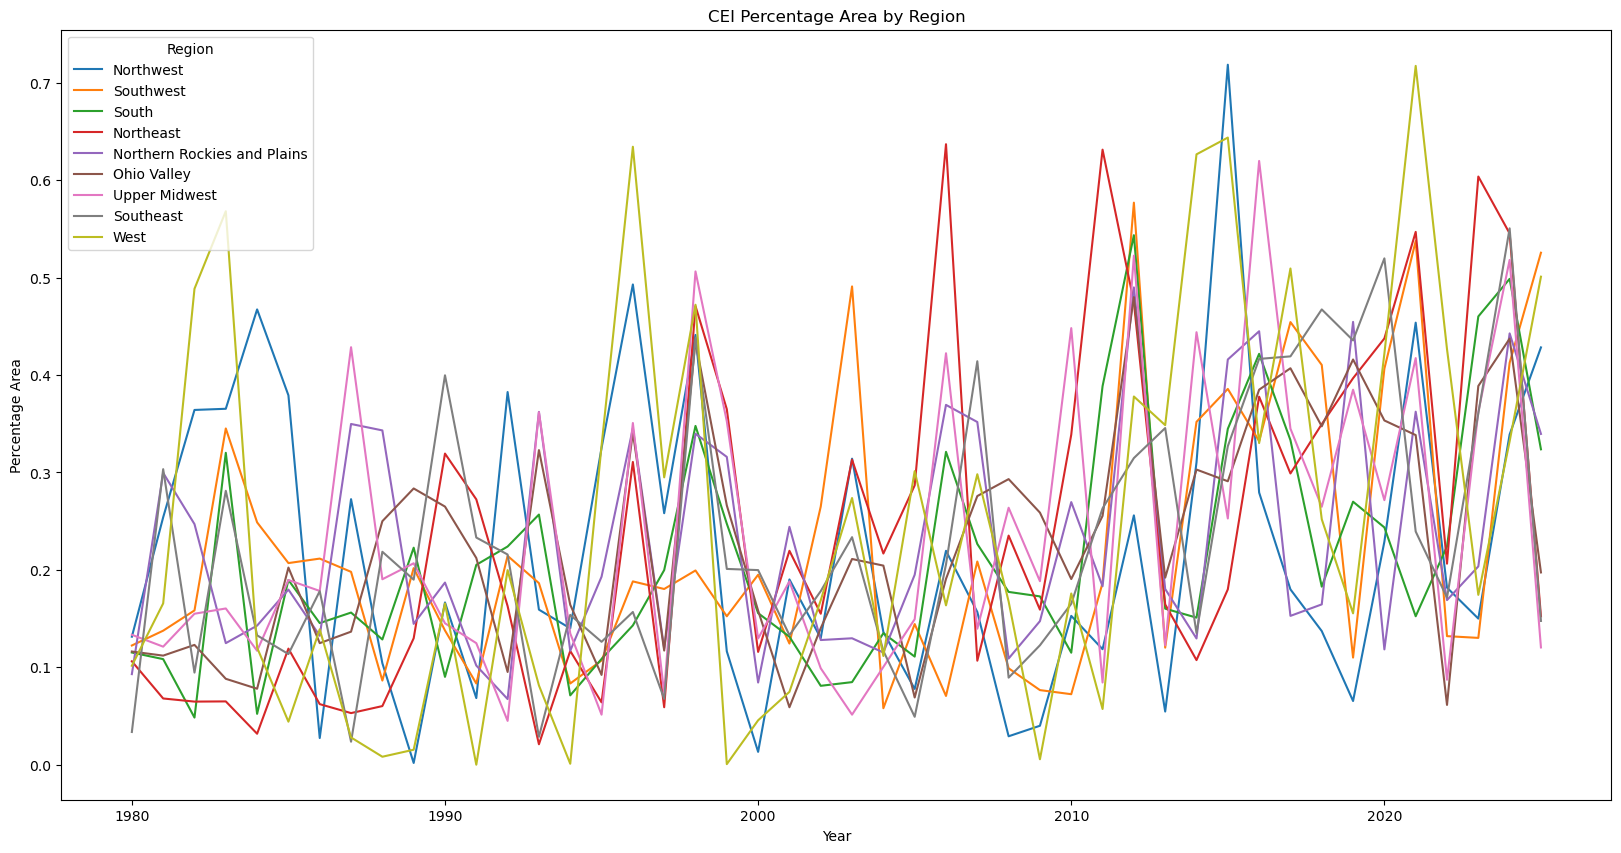

In [81]:
# CEI Time Recent History by Region
plt.figure(figsize=(20, 10))
sns.lineplot(data=cei_data_recent, x='Year', y='Percentage Area', hue='Region')
plt.title(f'CEI Percentage Area by Region')
plt.xlabel('Year')
plt.ylabel('Percentage Area')
plt.show()

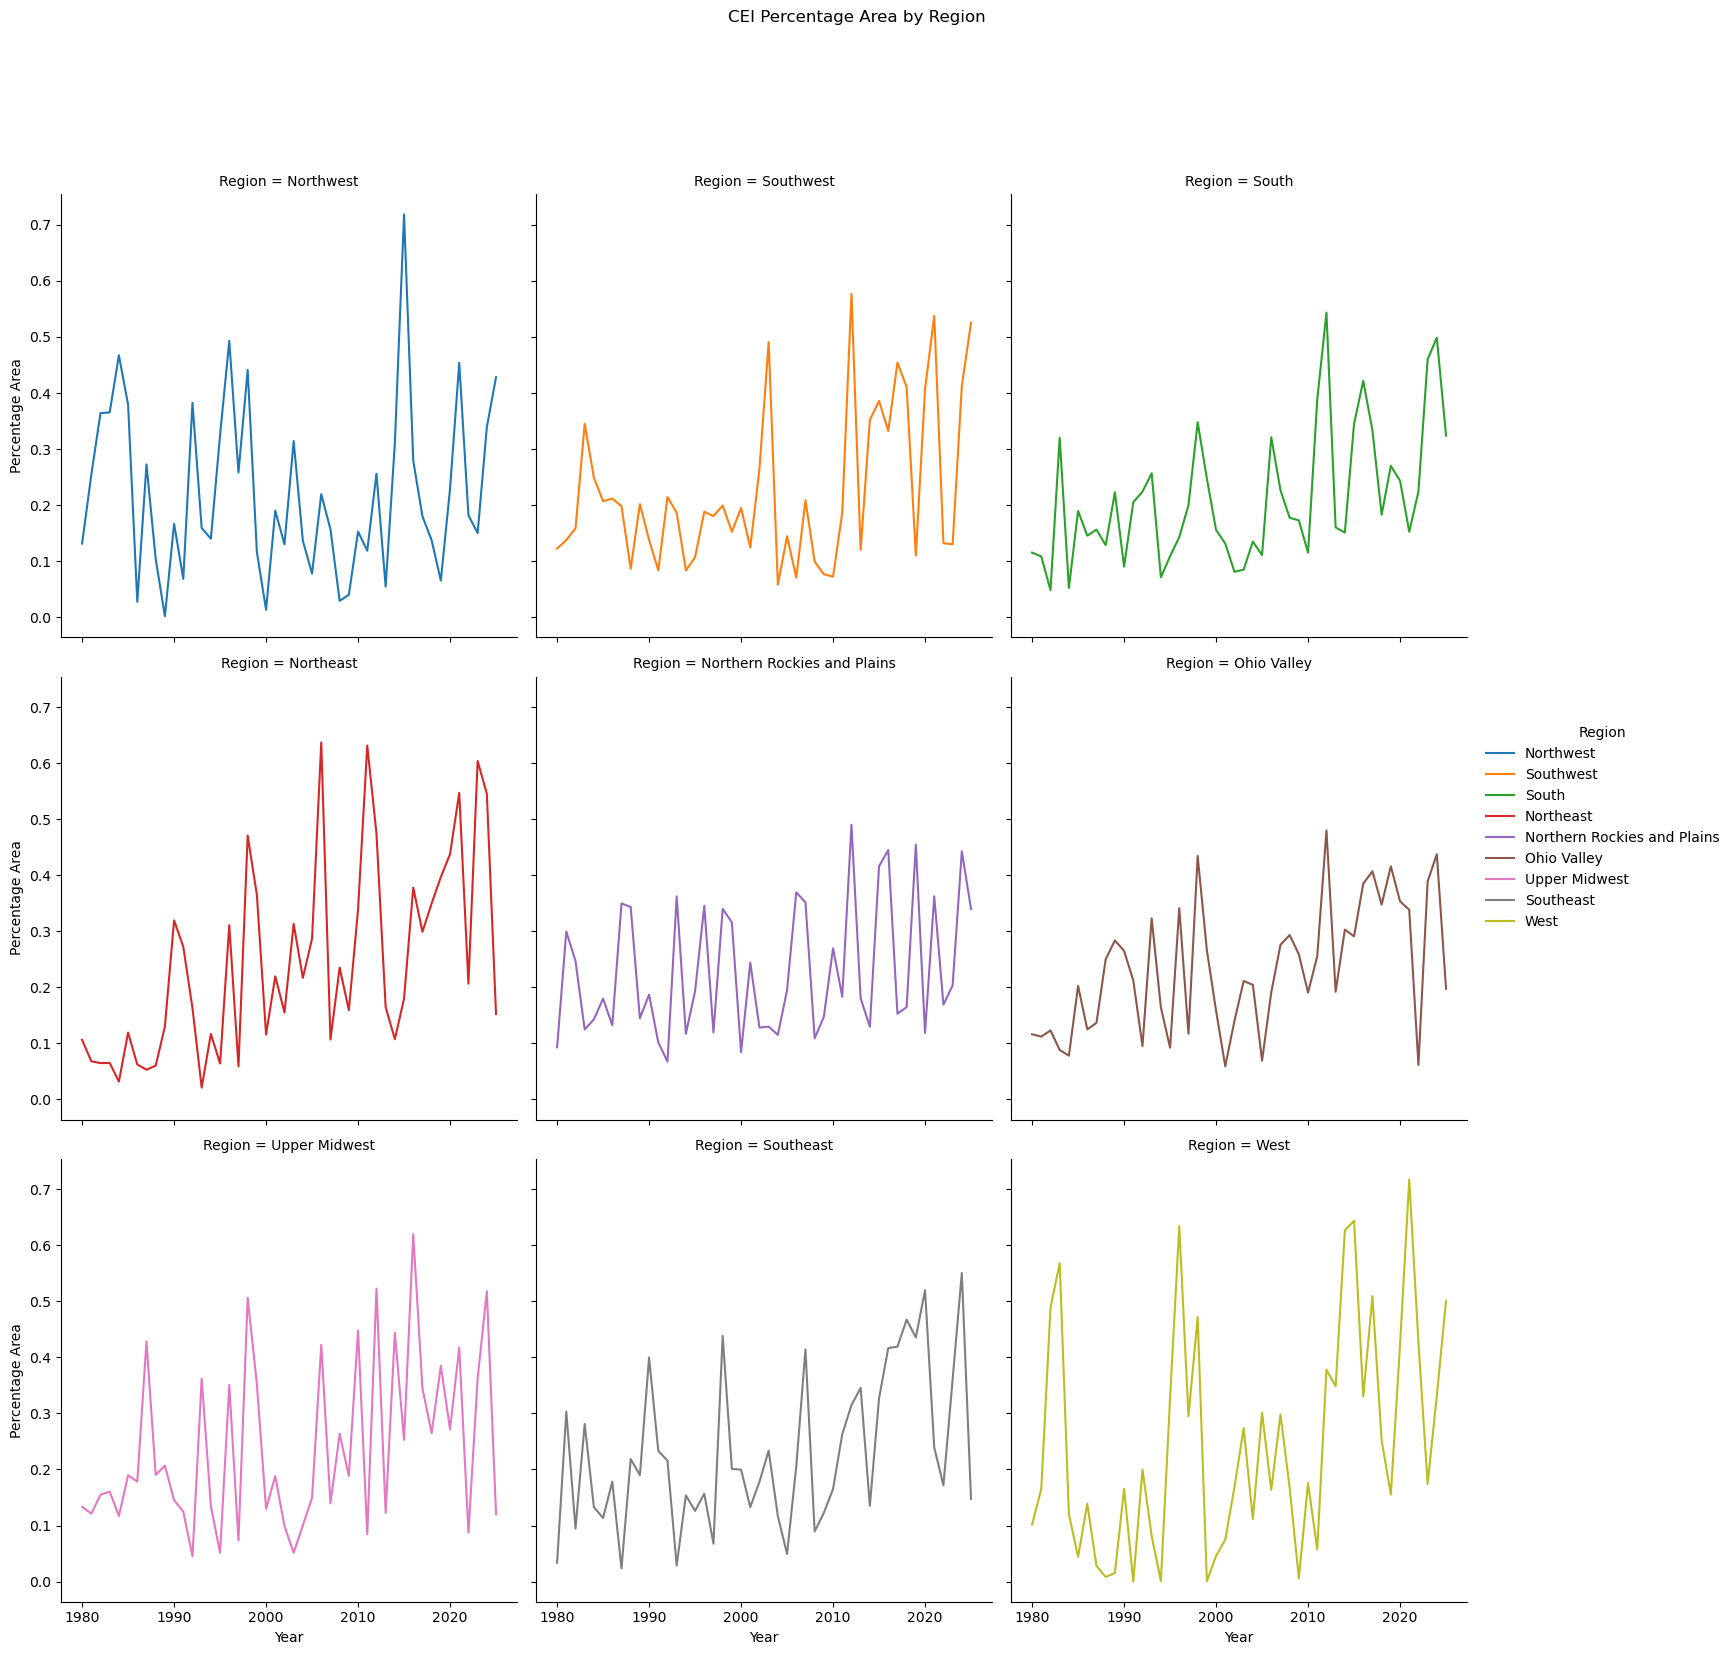

In [82]:
# CEI Time Recent History by Region

g = sns.relplot(
    data=cei_data_recent,
    x='Year', y='Percentage Area', hue="Region", estimator=None,col='Region',col_wrap=3, kind="line", linewidth=1.5)

plt.suptitle(f'CEI Percentage Area by Region',y = 1.1)


plt.show()

### 